# Eigenvalues in the wild: meeting the market

With our exercises within the simulation laboratory (`narrative_rmt_simulations.ipynb`) we earned essentially three things: (i) what are the thin-tailed **null models** (semicircle, Marchenko–Pastur, and their $q$-dependence); (ii)  **how fat tails corrupt spectra** (localised fake factors from single events, and delocalised impostors from common volatility); and (iii) a **"ranked" toolbox** of cleaning schemes tested against a spiked covatiance truth (sample < clipping < Ledoit–Wolf ≲ RIE). In this notebook we now try to apply the lessons learned tto real market data, namely **S&P constituents first, futures second.**

Here, the crucial epistemic difference with respect to the simulation lab is that, as every quant practitioner in history, we are oblivious about the udnerlying truth. Every claim we will make will have to be defended out-of-sample or by robustness across windows. It is going ti be a lot of fun (with the occasional cry here and there, of course).

Our master plan:

**Data acquisition (Part 0).** We get daily log-returns of about 200 liquid current S&P 500 consituents with their GICS sector. We clean the data dropping any with more than 5% of the days in the window. Although we download a few years worth of data, we will confine our analysis to one or two years time windows (practitioner's regime). To this, we add also visualisation tools for single asset (and cumulative) returns.  

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import importlib, rmt_lab                  # we are still editing the module:
importlib.reload(rmt_lab)                  # pick up edits without a kernel restart

from rmt_lab import (                     # the same toolkit — that is the point
    sample_cov, sample_corr, mp_pdf, mp_edges,
    eigh_desc, ipr, xi_clip, lw_shrinkage, xi_rie, recompose, clean_cov,
    min_var_weights, portfolio_variance, max_to_sum_ratio, day_scale, kappa,
    spike_overlap2, spike_ell_from_lambda, bbp_threshold,
)

SEED = 20260901
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3 = "C0", "C1", "C2", "C3"

DATA_DIR = "data"                         # gitignored cache
print("toolkit loaded")

toolkit loaded


## Part 0 — Yearning for some data mining

How do we get our data? Remember we want to build a $X \in \mathbb{R}^{N \times T}$ matrix of log-returns (with assets in rows and time in columns, as per standard convention). Of course we want it already "clean" enough that we can actually have some trust in computing the ESD in the first place. To do so, we are going to applu a (relatively) strict protocol of data mining and hygene.

**The Protocol:**

- **What data?** ~200 liquid current S&P 500 constituents *embedded with their GICS sector*. Of ocurse, these will carry *survivorship bias*, but for our scope at the moment it is OK (although we must be aware of it, of course);
- **Where do we get them?** We use adjusted closes via `yfinance` and cache them to `data/` (gitignored, but fast to run really);
- **Returns:** we use daily log-returns. In particular, we do absolutely **no winsorising, no clipping**. These procedures would kill the tails which are curcial, especially when fat!
- **Missing data handling:** we drop any name with more than ~5% missing days in the chosen time window and we never forward-fill returns (no fabricated data, we do not the distributions behind them).
- **Which time windows?** We keep the full panel, and slice per-Part: $N \approx 200$, $T = 252$ or $504$ to get $q \approx 0.4$–$0.8$, namely a typical practitioner's regime. Of course we download much more data regardless for checks about assets' distributions.

In [67]:
UNIVERSE = {
    "Info Tech": ["AAPL","MSFT","NVDA","AVGO","ORCL","CRM","ADBE","AMD","QCOM","TXN",
                  "INTC","INTU","IBM","CSCO","ACN","AMAT","MU","LRCX","KLAC","ADI",
                  "SNPS","CDNS","PANW","ANET","NOW","APH","MSI","GLW","HPQ","NXPI"],
    "Comm Svcs": ["GOOGL","META","NFLX","DIS","CMCSA","VZ","T","TMUS","CHTR","EA",
                  "TTWO","OMC"],
    "Financials": ["BRK-B","JPM","BAC","WFC","C","GS","MS","SCHW","BLK","BX","KKR",
                   "AXP","V","MA","COF","USB","PNC","TFC","BK","AIG","MET","PRU",
                   "ALL","TRV","CB","PGR","MMC","AON","SPGI","MCO","ICE","CME"],
    "Health Care": ["LLY","UNH","JNJ","ABBV","MRK","PFE","TMO","ABT","DHR","AMGN",
                    "GILD","BMY","MDT","ISRG","SYK","BSX","VRTX","REGN","CI","ELV",
                    "CVS","HUM","BDX","EW","A","IDXX","MCK","HCA","ZTS"],
    "Cons Disc": ["AMZN","TSLA","HD","MCD","NKE","SBUX","LOW","TJX","BKNG","MAR",
                  "HLT","GM","F","ROST","YUM","CMG","ORLY","AZO","EBAY","DHI",
                  "LEN","RCL"],
    "Cons Staples": ["PG","KO","PEP","COST","WMT","PM","MO","MDLZ","CL","KMB","GIS",
                     "SYY","KR","STZ","HSY","TGT","DG","DLTR","EL"],
    "Energy": ["XOM","CVX","COP","SLB","EOG","MPC","PSX","VLO","OXY","HAL","WMB",
               "KMI","OKE","DVN","BKR"],
    "Industrials": ["CAT","DE","HON","UNP","UPS","FDX","BA","LMT","RTX","NOC","GD",
                    "GE","MMM","EMR","ETN","ITW","PH","CMI","CSX","NSC","WM","RSG",
                    "PCAR","ROK","DOV","AME","URI","PWR"],
    "Materials": ["LIN","APD","SHW","ECL","FCX","NEM","NUE","DD","PPG","VMC","MLM"],
    "Utilities": ["NEE","DUK","SO","D","AEP","EXC","SRE","XEL","ED","PEG","WEC","ES"],
    "Real Estate": ["PLD","AMT","CCI","EQIX","SPG","O","PSA","WELL","DLR","AVB"],
}
SECTOR_OF = {t: s for s, ts in UNIVERSE.items() for t in ts}
TICKERS = sorted(SECTOR_OF)
START = "2010-01-01"

print(f"{len(TICKERS)} tickers across {len(UNIVERSE)} sectors:")
for s, ts in UNIVERSE.items():
    print(f"  {s:14s} {len(ts):3d}")

220 tickers across 11 sectors:
  Info Tech       30
  Comm Svcs       12
  Financials      32
  Health Care     29
  Cons Disc       22
  Cons Staples    19
  Energy          15
  Industrials     28
  Materials       11
  Utilities       12
  Real Estate     10


In [68]:
FORCE_REFRESH = False
DATA_DIR = os.path.abspath(DATA_DIR)                 # pin it: cwd varies across IDEs
os.makedirs(DATA_DIR, exist_ok=True)
print(f"working dir : {os.getcwd()}")
print(f"cache dir   : {DATA_DIR}")
CACHE = os.path.join(DATA_DIR, "sp_prices.parquet")
CACHE_PKL = os.path.join(DATA_DIR, "sp_prices.pkl")   # fallback if pyarrow is absent

def fetch_prices(tickers, start, force=False):
    if not force:
        for path, reader in ((CACHE, pd.read_parquet), (CACHE_PKL, pd.read_pickle)):
            if os.path.exists(path):
                px = reader(path)
                print(f"loaded cache {path}: {px.shape[1]} names x {px.shape[0]} days "
                      f"({px.index[0].date()} to {px.index[-1].date()})")
                return px
    try:
        import io, logging, contextlib
        import yfinance as yf
        logging.getLogger("yfinance").setLevel(logging.CRITICAL)
        with contextlib.redirect_stderr(io.StringIO()):          # yahoo failures are noisy
            raw = yf.download(tickers, start=start, auto_adjust=True,
                              progress=False, threads=True)
        px = raw["Close"].sort_index()
        px = px.dropna(axis=1, how="all")
        if px.empty:
            raise RuntimeError("download returned nothing")
    except Exception as e:
        print(f"OFFLINE or download failed ({type(e).__name__}).")
        print("Run this cell once on a connected machine to build the cache; "
              "everything downstream will then work from data/ with no network.")
        return None
    try:
        px.to_parquet(CACHE)
        written = CACHE
    except Exception as e:
        print(f"parquet write failed ({type(e).__name__}: {e}) -> falling back to pickle")
        px.to_pickle(CACHE_PKL)
        written = CACHE_PKL
    ok = os.path.exists(written) and os.path.getsize(written) > 0
    print(f"cache written: {written}  ({os.path.getsize(written)/1e6:.1f} MB)" if ok
          else f"CACHE WRITE FAILED at {written} — check permissions/path")
    print(f"{px.shape[1]} names x {px.shape[0]} days ({px.index[0].date()} to {px.index[-1].date()})")
    return px

px = fetch_prices(TICKERS, START, force=FORCE_REFRESH)

working dir : c:\Users\mrcga\Quant_Preparation\Quant&RMT&FatTails
cache dir   : c:\Users\mrcga\Quant_Preparation\Quant&RMT&FatTails\data
loaded cache c:\Users\mrcga\Quant_Preparation\Quant&RMT&FatTails\data\sp_prices.parquet: 218 names x 4193 days (2010-01-04 to 2026-09-03)


In [69]:
if px is None:
    print("no data yet - nothing to inspect")
else:
    first_day = px.apply(lambda s: s.first_valid_index())
    missing = px.isna().mean()
    report = pd.DataFrame({"first date": first_day.dt.date, "missing %": (100*missing).round(1),
                           "sector": pd.Series(SECTOR_OF)})
    print(f"data requested: {len(TICKERS)}   delivered: {px.shape[1]}")
    late = report.sort_values("first date", ascending=False).head(10)
    print("\nten latest listings (they sit out early windows):")
    display(late)
    absent = sorted(set(TICKERS) - set(px.columns))
    print("not delivered by yahoo at all:", absent if absent else "none")

data requested: 220   delivered: 218

ten latest listings (they sit out early windows):


,first date,missing %,sector
EA,2026-07-17,99.9,Comm Svcs
AVB,2026-07-17,99.4,Real Estate
ANET,2014-06-06,26.5,Info Tech
HLT,2013-12-12,23.7,Cons Disc
ZTS,2013-02-01,18.5,Health Care
ABBV,2013-01-02,18.0,Health Care
PANW,2012-07-20,15.3,Info Tech
NOW,2012-06-29,15.0,Info Tech
META,2012-05-18,14.3,Comm Svcs
PSX,2012-04-12,13.7,Energy


not delivered by yahoo at all: ['BK', 'MMC']


In [70]:
if px is not None:
    rets_log = np.log(px).diff().iloc[1:]      # default: time aggregation, tails, spectra
    rets_net = px.pct_change().iloc[1:]        # net (= raw = simple): aggregates across ASSETS
    rets_full = rets_log                       # back-compat alias used below

def load_returns(start, end, max_missing=0.05, kind="log", verbose=True):
    """Window -> (X, names, dates): X is (N, T), module convention (assets in rows).
    kind='log' (default) or 'net'. Only net returns aggregate linearly across assets,
    so portfolio accounting (Part 5) uses net; daily they differ at O(r^2)."""
    src = rets_log if kind == "log" else rets_net
    r = src.loc[start:end]
    keep = r.columns[r.isna().mean() <= max_missing]
    r = r[keep].dropna(axis=0, how="any")
    X = r.to_numpy().T
    if verbose:
        n, t = X.shape
        print(f"[{start} to {end}]  N = {n}  T = {t}  q = N/T = {n/t:.4f}   "
              f"(dropped {len(src.columns) - n} names, kind={kind})")
    return X, list(r.columns), r.index

if px is not None:
    X21, names21, dates21 = load_returns("2021-01-01", "2022-12-31")
    X15, names15, dates15 = load_returns("2015-01-01", "2016-12-31")
else:
    print("no data yet - loader defined, demo skipped")

[2021-01-01 to 2022-12-31]  N = 216  T = 503  q = N/T = 0.4294   (dropped 2 names, kind=log)
[2015-01-01 to 2016-12-31]  N = 216  T = 504  q = N/T = 0.4286   (dropped 2 names, kind=log)


Now a bit of visualisation. In order: (i) cumulative log returns (equal weights) and cross-section mean aboslute deviation (MAD); (ii) single asset visualisation of $P(|r| > x)$ to look into the (essentiallu ubiquitous) presence of fat tails. 

[2010-01-01 to None]  N = 201  T = 4188  q = N/T = 0.0480   (dropped 17 names, kind=log)


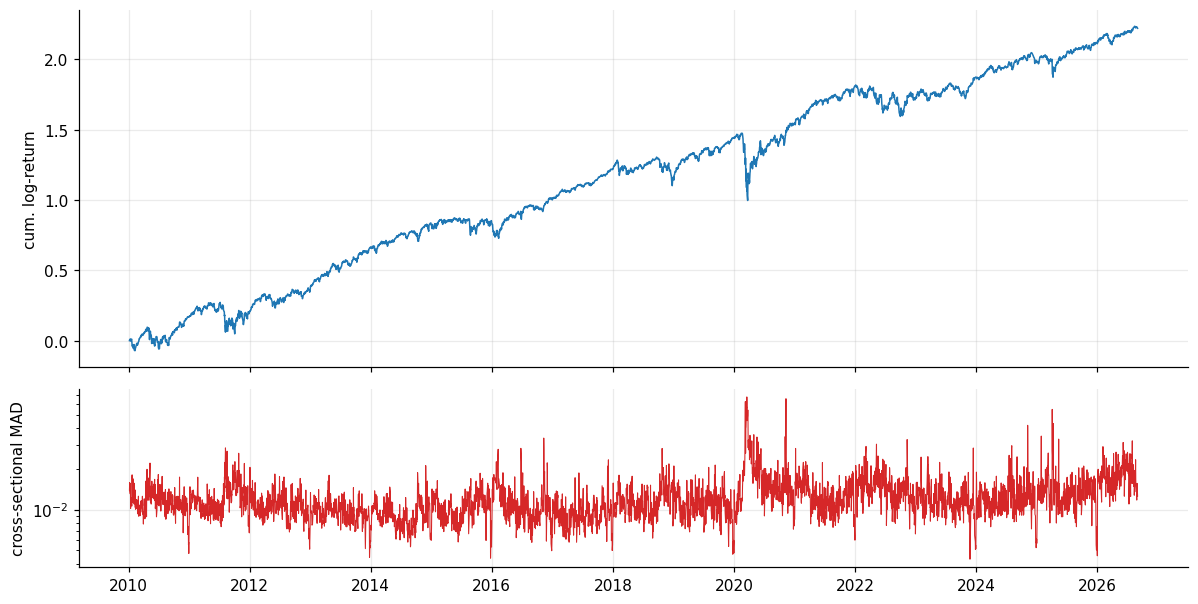

In [71]:
if px is not None:
    Xall, names_all, dates_all = load_returns(START, None, max_missing=0.02, verbose=True)
    eq_weight = Xall.mean(axis=0).cumsum()
    disp = np.sqrt(np.pi / 2.0) * np.mean(np.abs(Xall - np.mean(Xall, axis=0)), axis=0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(dates_all, eq_weight, color=C0, lw=1.0)
    ax1.set_ylabel("cum. log-return")
    ax2.semilogy(dates_all, disp, color=C3, lw=0.7)
    ax2.set_ylabel("cross-sectional MAD")
    plt.tight_layout()

The upper panel of the plot shows the overall growth of S&P 500 cumulative returns, so really nothing new there. Now, the lower pnale shows instead the cross-section MAD of the log-returns. This is a proxy for the $\sigma_t$ of Part 5 of `narrative_rmt_simulations.ipynb`, i.e., the common variance within the market.

Now, if we were to pick a single stock. Would its return dsipaly a fat tail? And if so, in which regime? We show this below for AMZ (just change the name of the stock to see a different one). We also (i) distinguish between positive and negative tails (asymmetry is always information after all), and also show the share of the fourth-moment sum owned by the single largest day ($R_4$) and the three largest days themselves.

R4: 0.26
three largest |moves| — investigate, never delete:
   2022-02-03   -0.306
   2022-10-27   -0.282
   2013-07-25   +0.259


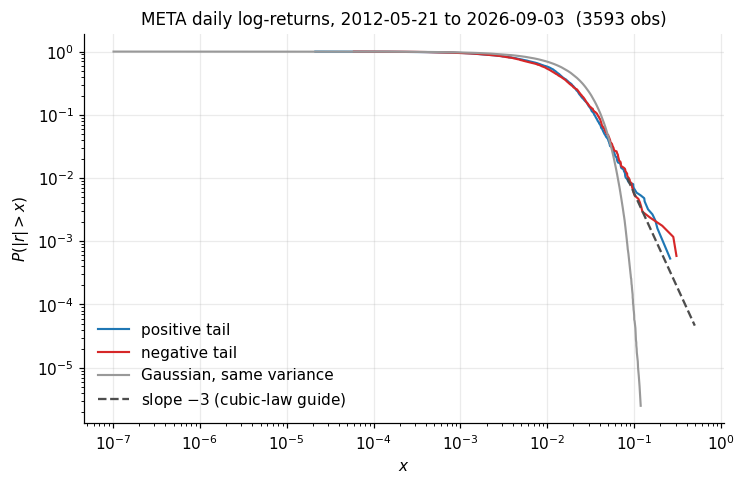

In [72]:
TICKER = "META"                    # <- change me and re-run

if px is None:
    print("no data yet")
else:
    r = rets_full[TICKER].dropna()
    pos = np.sort(r[r > 0].to_numpy())
    neg = np.sort(-r[r < 0].to_numpy())
    rng_tail = np.random.default_rng(0)
    gauss = np.sort(np.abs(rng_tail.standard_normal(400_000) * r.std()))

    def ccdf(a):
        return a, 1.0 - np.arange(1, a.size + 1) / (a.size + 1)

    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    for a, c_, lab in ((pos, C0, "positive tail"), (neg, C3, "negative tail"),
                       (gauss, "0.6", "Gaussian, same variance")):
        x, s = ccdf(a)
        ax.loglog(x, s, color=c_, lw=1.4, label=lab)
    x0 = np.quantile(np.concatenate([pos, neg]), 0.99)
    xg = np.array([x0, x0 * 6])
    ax.loglog(xg, 0.01 * (xg / x0) ** (-3.0), ls="--", color="0.3",
              label=r"slope $-3$ (cubic-law guide)")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$P(|r| > x)$")
    ax.set_title(f"{TICKER} daily log-returns, {r.index[0].date()} to {r.index[-1].date()}  "
                 f"({r.size} obs)")
    ax.legend()

    r4 = max_to_sum_ratio(r.to_numpy(), 4)[-1]
    print(f"R4: {r4:.2f}")
    print("three largest |moves| — investigate, never delete:")
    for d, v in r.abs().nlargest(3).items():
        print(f"   {d.date()}   {r[d]:+.3f}")

## Part 1 — A first ESD: S&P vs MP

Alright, time to get into it. To wit, enough foreplay. We now take a  windown, build the sample **correlation** matrix (unit diagonal, so that in a perfect world MP applied with $\sigma^2 = 1$) and just ask: *how much of this spectrum is
explained by "nothing is going on, i.e., randomness"?*

To investigate this, we effectively employ two thresholds, each against the **same Gaussian, stationary null**. We will challange this null later on in Part 3 and Part 4. In particular, the thresholds are:

1. **The naive MP edge** $(1+\sqrt q)^2$, namely the textbook line. We will see how this fails since the market absorbs a large share of the total variance, leaving the noise band narrower than $\sigma^2 = 1$ assumes;
2. **An effective edge**. This is build by removing the market mode and then spreading the residual trace over the remaining $N-1$ directions, i.e., $\sigma^2_{\rm eff} = (N-\lambda_1)/(N-1)$ with $q_{\rm eff} = (N-1)/T$. Then one just recimputes the edge. See Laloux, Cizeau, Bouchaud, and Potters (1999), PRL 83, 1467.


Finally, we will employ **TW / LDT** to try to give essentially a p-value rather than a yes/no to any outliers.

AH! A notation statement. In `narrative_rmt_simulations.ipynb` we used the notation $\lambda_{\rm max}$ for the top realised eigenvalue. From here on out we will use instead $\lambda_1$ and in general we will label in decreasing order of magnitude $\lambda_1 > \lambda_2 >\, ...\, > \lambda_{N}$.

In [73]:
def mp_fit_k(lam, n, t, k=1):
    """Effective MP null after removing the k largest modes
      residual trace spread over the remaining n-k directions,
      q_eff = (n-k)/T."""
    sig2 = (lam.sum() - lam[:k].sum()) / (n - k)
    q_eff = (n - k) / t
    return sig2, q_eff, mp_edges(q_eff, sig2)[1]

def tw_threshold(n, t, sig2=1.0, quantile=0.9794):
    """Johnstone centering/scaling for the top Wishart eigenvalue; default quantile
    is the 95th percentile of TW (beta=1)."""
    mu = (np.sqrt(t - 1) + np.sqrt(n)) ** 2 / t
    sc = (np.sqrt(t - 1) + np.sqrt(n)) / t * (1 / np.sqrt(t - 1) + 1 / np.sqrt(n)) ** (1 / 3)
    return sig2 * (mu + quantile * sc)

def psi_plus(x, q, sig2=1.0, npts=2000):
    """Right large-deviation rate: P(lambda > x) ~ exp(-N * Psi_+(x))."""
    lm, lp = mp_edges(q, sig2)
    x = np.atleast_1d(np.asarray(x, float))
    out = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi > lp:
            tt = np.linspace(lp, xi, npts)
            out[i] = 0.5 * np.trapezoid(np.sqrt((tt - lm) * (tt - lp)) / (q * sig2 * tt), tt)
    return out

In [74]:
if px is not None:
    WIN_DAYS = 504                                   # ~2 years; one edit changes the window easily
    w_end, w_start = rets_log.index[-1], rets_log.index[-WIN_DAYS]
    Xw, names_w, dates_w = load_returns(w_start, w_end, max_missing=0.02)

    Cw = sample_corr(Xw, demean=True)
    lam_w, U_w = eigh_desc(Cw)
    Nw, Tw = Xw.shape
    qw = Nw / Tw
    rho_bar = Cw[np.triu_indices(Nw, 1)].mean()

    print(f"window: {dates_w[0].date()} to {dates_w[-1].date()}")
    print(f"mean pairwise correlation rho_bar = {rho_bar:.3f}")
    print(f"lambda_1 = {lam_w[0]:.1f}")
    print(f"lambda_1 explains {100 * lam_w[0] / Nw:.1f}% of the total variance "
          f"(trace = N = {Nw})")

[2024-08-30 00:00:00 to 2026-09-03 00:00:00]  N = 216  T = 501  q = N/T = 0.4311   (dropped 2 names, kind=log)
window: 2024-08-30 to 2026-08-31
mean pairwise correlation rho_bar = 0.193
lambda_1 = 47.2
lambda_1 explains 21.9% of the total variance (trace = N = 216)


above naive edge      : 10
above effective edge  : 13
above TW 95%  (effective edge) : 13


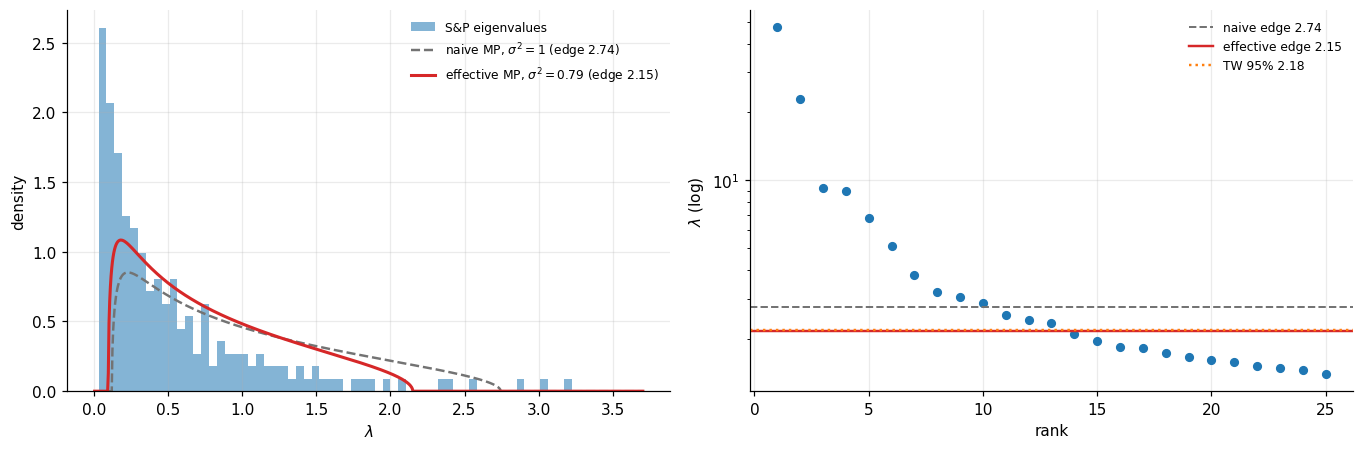

In [75]:
if px is not None:
    edge_naive = mp_edges(qw, 1.0)[1]
    sig2_eff, q_eff, edge_eff = mp_fit_k(lam_w, Nw, Tw, k=1)
    tw95 = tw_threshold(Nw - 1, Tw, sig2_eff)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

    xs = np.linspace(1e-3, edge_naive * 1.35, 800)
    ax1.hist(lam_w[lam_w < edge_naive * 1.35], bins=60, density=True, color=C0,
             alpha=0.55, label="S&P eigenvalues")
    ax1.plot(xs, mp_pdf(xs, qw, 1.0), color="0.45", lw=1.6, ls="--",
             label=rf"naive MP, $\sigma^2=1$ (edge {edge_naive:.2f})")
    ax1.plot(xs, mp_pdf(xs, q_eff, sig2_eff), color=C3, lw=2,
             label=rf"effective MP, $\sigma^2={sig2_eff:.2f}$ (edge {edge_eff:.2f})")
    ax1.set_xlabel(r"$\lambda$"); ax1.set_ylabel("density")
    ax1.legend(fontsize=8)

    top = 25
    ax2.semilogy(np.arange(1, top + 1), lam_w[:top], "o", color=C0, ms=5)
    ax2.axhline(edge_naive, color="0.45", ls="--", lw=1.3, label=f"naive edge {edge_naive:.2f}")
    ax2.axhline(edge_eff, color=C3, lw=1.6, label=f"effective edge {edge_eff:.2f}")
    ax2.axhline(tw95, color=C1, ls=":", lw=1.6, label=f"TW 95% {tw95:.2f}")
    ax2.set_xlabel("rank"); ax2.set_ylabel(r"$\lambda$ (log)")
    ax2.legend(fontsize=8)
    plt.tight_layout()

    n_naive = int((lam_w > edge_naive).sum())
    n_eff = int((lam_w > edge_eff).sum())
    n_tw = int((lam_w > tw95).sum())
    print(f"above naive edge      : {n_naive}")
    print(f"above effective edge  : {n_eff}")
    print(f"above TW 95%  (effective edge) : {n_tw}")

The plot above shows: (i) the bulk of the S&P EDS superimposed with the MP distribution with the naive and effective edges (left panel); and (ii) the top part of the spectrum (i.e., the top 25 entries) with the naive and effective edges, as well as the TW 95% confidence band.

It is clear from the plot that **MP does not seem to be a good fit if we only remove the top market mode**. In fact the left plot recalls the elliptical fat-tailed plot we obtained in Part 5 of `narrative_rmt_simulations.ipynb`. We will of course investigate this. Do note though that the removal of more market mode can make things work a bit better, see e.g., Laloux, Cizeau, Bouchaud, and Potters (1999), PRL 83, 1467. 

Additioanlly, a large portion of the eigenvalues are concentrate to the left and quite a few show up as signifcant outliers. Now, are they genuine outliers even considering LDT?

In [76]:
if px is not None:
    k_show = max(n_eff + 3, 12)
    ld = psi_plus(lam_w[:k_show], q_eff, sig2_eff)
    tbl = pd.DataFrame({
        "lambda": lam_w[:k_show].round(3),
        "> eff. edge": np.where(lam_w[:k_show] > edge_eff, "yes", "-"),
        "LD cost N*Psi": (Nw * ld).round(1),
        "IPR": [float(ipr(U_w[:, i])) for i in range(k_show)],
        "top |loading|": [names_w[int(np.argmax(np.abs(U_w[:, i])))] for i in range(k_show)],
        "top sector": [SECTOR_OF.get(names_w[int(np.argmax(np.abs(U_w[:, i])))], "?")
                       for i in range(k_show)],
    }, index=[f"lam_{i+1}" for i in range(k_show)])
    print(f"delocalised reference 3/N = {3/Nw:.4f}   (IPR near it = spread over everything; "
          f"near 1 = one stock)")
    display(tbl.style.format({"IPR": "{:.4f}"}))

delocalised reference 3/N = 0.0139   (IPR near it = spread over everything; near 1 = one stock)


C:\Users\mrcga\AppData\Local\Temp\ipykernel_12244\2339377894.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "IPR": [float(ipr(U_w[:, i])) for i in range(k_show)],


,lambda,> eff. edge,LD cost N*Psi,IPR,top |loading|,top sector
lam_1,47.213000,yes,13214.000000,0.0068,ITW,Industrials
lam_2,22.750000,yes,5638.700000,0.0109,ED,Utilities
lam_3,9.258000,yes,1649.000000,0.0380,COP,Energy
lam_4,8.982000,yes,1571.800000,0.0170,NOW,Info Tech
lam_5,6.830000,yes,987.600000,0.0108,PEG,Utilities
lam_6,5.100000,yes,548.700000,0.0119,WFC,Financials
lam_7,3.828000,yes,259.300000,0.0188,ELV,Health Care
lam_8,3.225000,yes,140.500000,0.0152,CVS,Health Care
lam_9,3.041000,yes,107.900000,0.0165,UNH,Health Care
lam_10,2.880000,yes,81.300000,0.0208,NOC,Industrials


We see that all the "above the edge" eigenvalues are moved enough from the threshold to be identified as signal (within a Gaussian noise world) even when considering LDT. But how sure are we of them being genuine? At this stage not much of course!

In particular we can run a little experiment for calibration of intuition (following the spirit of `narrative_rmt_simulations.ipynb` essentially). Namely, **what would we see if we *knew* the answer?**

Indeed, the counts above are only as good as the null they price. Different null, different story. We thus use the same $N$, $T$ and market strength but with a four-times spiked covariance matrix: once with Gaussian entries (the null's own assumptions) and once with elliptical $t(3)$ (fat tails as we saw in the single assets looking at the returns name by name).

This should help us in understanding how to *read* the S&P number. To wit,  what a detection count looks like when it
is honest, and what it looks like when fat tails inflate it. Some of this has already been discussed in the simulation notebook. But a direct refresh is not bad. It surealy helps me.

In [77]:
from rmt_lab import spiked_cov, returns_student, returns_gaussian

N_c, T_c, K_TRUE = 200, 504, 4
rng_c = np.random.default_rng(11)
C_c, _ = spiked_cov(N_c, [70.0, 6.0, 4.0, 3.0], rng_c, market=True)   # market + 3 sectors

rows = []
for lab, Xc in (("Gaussian", returns_gaussian(N_c, T_c, rng_c, cov=C_c)),
                ("elliptical t(3)",
                 returns_student(N_c, T_c, 3.0, rng_c, cov=C_c, elliptical=True))):
    lam_c, _ = eigh_desc(sample_corr(Xc, demean=True))
    e_naive = mp_edges(N_c / T_c, 1.0)[1]
    s2_c, q_c, e_eff = mp_fit_k(lam_c, N_c, T_c, k=1)
    rows.append({"world": lab, "true factors": K_TRUE, "lambda_1": round(lam_c[0], 1),
                 "above naive edge": int((lam_c > e_naive).sum()),
                 "sigma2_eff": round(s2_c, 3),
                 "above effective edge": int((lam_c > e_eff).sum()),
                 "above TW95": int((lam_c > tw_threshold(N_c - 1, T_c, s2_c)).sum())})
pd.DataFrame(rows).set_index("world")

,true factors,lambda_1,above naive edge,sigma2_eff,above effective edge,above TW95
world,,,,,,
Gaussian,4,50.9,3,0.749,4,4
elliptical t(3),4,48.0,12,0.764,17,17


OK. The table numbers are quite interesting. Indeed, we find that: 

- **The naive edge always under-detects**. Here, the market mode is swallowing a large share of the variance and $\sigma^2 = 1$ then describes a noise band wider than the one the residual directions actually live in.
- **The effective edge is calibrated in a thin-tailed world**. To wit, with Gaussian entries it recovers exactly the planted count.
- **Fat tails inflate the count, as expected.** In this case, tthe effective edge reports several times the planted number.

Hence, we can say that any S&P count read off the effective edge is an **upper bound on the number of real factors**. Moreover, with some contamination by whatever the tails contribute. Now, it is time to move on to questionening the modes we have identified.

## Part 2 — What are the modes made of?

In Part 1 we identified the top outliers in the ESD, namely those eigenvalues whose value is too big to be explined (assuming gaussian noise) with neither TW nor LDT. However, we have absolutely no idea what produced these outliers. Indeed, these could be due to a genuine factor, a single wild stock or a wild day. 

Hence, we now turn to the question of analysing what each mode is made out of. To do so we will employ: 

- **Portraits.** A simple plot of the top eigenvectors $v_k$, one bar per stock, coloured by sector. We expect the market mode to be built with one single sign and roughly even, whilst a sector mode should be a long-short block structure. 
- **Localisation.** We employ our friendly IPR for each mode, pitted against a gaussian null. Here, a  delocalised mode will sit near $3/N$, whilst a mode living on one stock will sit near 1 (see also Part 4 of `narrative_rmt_simulations.ipynb`).
- **Reliability.** For each outlier we invert the BBP relation to estimate the population strength $\ell$ that would produce the respective $\lambda$. From this we can then read off the expected squared overlap $|\langle u_k, v_k\rangle|^2$ between the *sample* eigenvector and the *true* direction we wish we had.

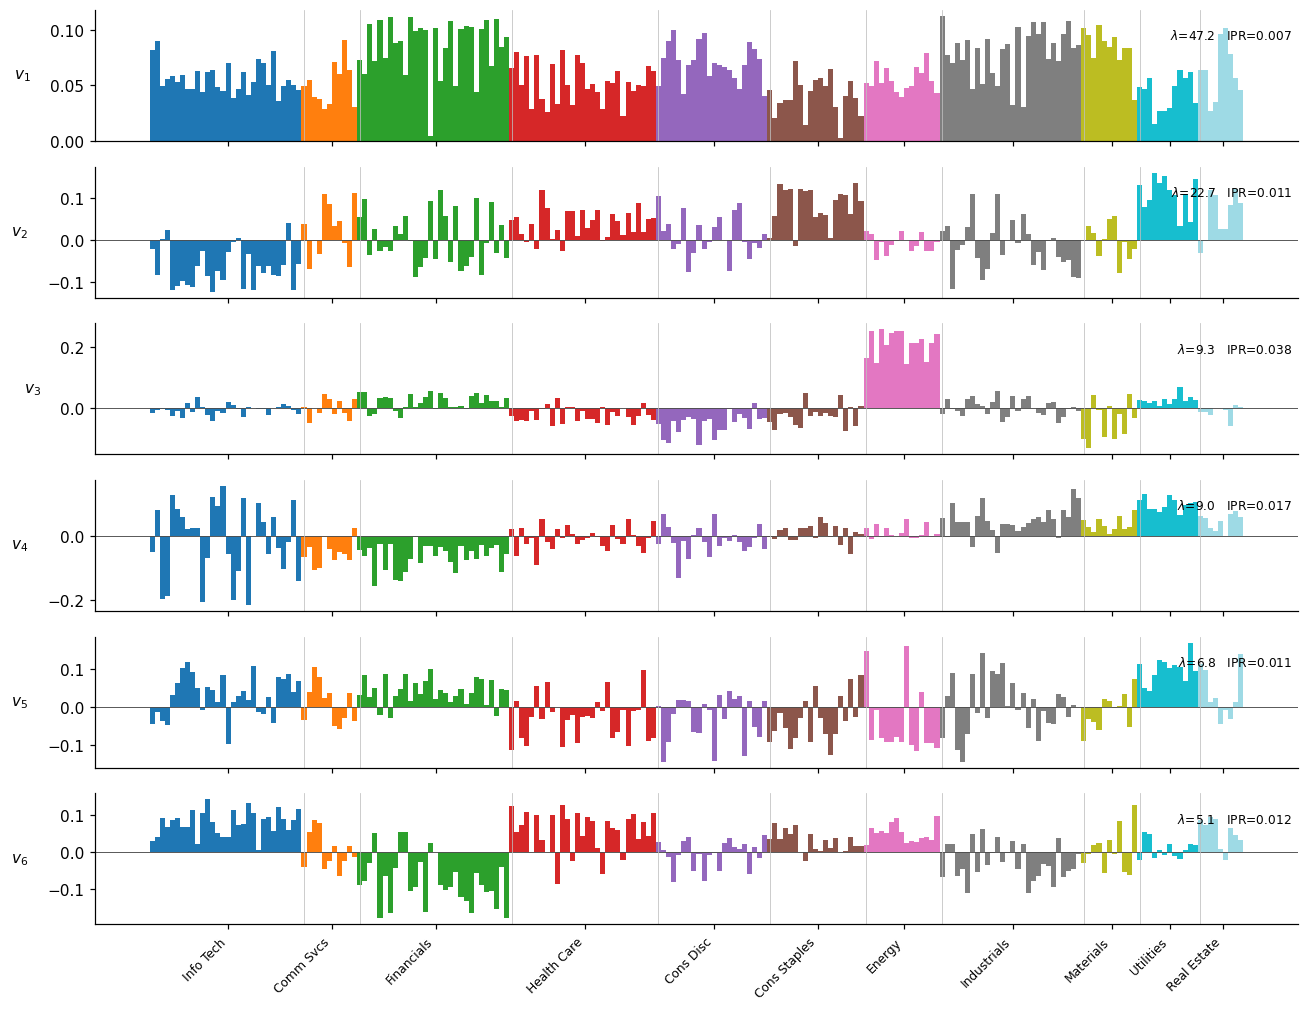

In [78]:
if px is not None:
    order = np.argsort([list(UNIVERSE).index(SECTOR_OF[n]) for n in names_w])
    secs_sorted = [SECTOR_OF[names_w[i]] for i in order]
    sec_list = list(UNIVERSE)
    cmap = plt.get_cmap("tab20")
    col_of = {s: cmap(i / max(len(sec_list) - 1, 1)) for i, s in enumerate(sec_list)}
    bar_cols = [col_of[s] for s in secs_sorted]
    bounds = [secs_sorted.index(s) for s in sec_list if s in secs_sorted]

    n_show = 6
    fig, axes = plt.subplots(n_show, 1, figsize=(12, 1.55 * n_show), sharex=True)
    for k, ax in enumerate(axes):
        v = U_w[order, k]
        v = v * np.sign(v.sum() if abs(v.sum()) > 1e-12 else 1.0)   # fix the sign convention
        ax.bar(np.arange(len(v)), v, color=bar_cols, width=1.0)
        ax.axhline(0, color="0.3", lw=0.6)
        ax.set_ylabel(f"$v_{{{k+1}}}$", rotation=0, labelpad=18, va="center")
        ax.text(0.995, 0.86, f"$\\lambda$={lam_w[k]:.1f}   IPR={ipr(U_w[:, k]).item():.3f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8)
        for b in bounds[1:]:
            ax.axvline(b, color="0.75", lw=0.5)
        ax.grid(False)
    axes[-1].set_xticks([(bounds + [len(order)])[i] / 2 + (bounds + [len(order)])[i + 1] / 2
                         for i in range(len(bounds))])
    axes[-1].set_xticklabels([s for s in sec_list if s in secs_sorted], rotation=45,
                             ha="right", fontsize=8)
    plt.tight_layout()

Well, damn! If I may say so. This is a good plot. To wit:

- **The market mode matches our expectations.** $v_1$ ($\lambda_1 = 47.2$) presents no sign flip, and its IPR ($0.0068$) is *below* the delocalised reference $3/N = 0.0139$, i.e., more spread out than a random direction.

- **The contribution to the market mode are uneven across sectors.** Financials and Industrials dominate whilst e.g.,Consumer Staples contribute less. We can look at these as measuring each name's **correlation with the market** (not its beta as we are looking at a correlation matrix here).

- **Below the market, every mode is a long-short trade.** To understand this let us look at some of the top eigenvectors. We find that (i) $v_2$ is negative across Info Tech and positive on Utilities, Staples and Real Estate; (ii) $v_3$ is essentially just Energy; and (iii) $v_6$ is Info Tech and Health against Financials and Industrials. To use the trader's terms (hopefully I get this right) $v_1$ is the only mode that is **long beta** — namely, net exposure to the index, $216+/0-$ — while the rest are roughly **beta-neutral**. That is what, in principle, should make them tradeable as *relative* bets rather than as the index in disguise.

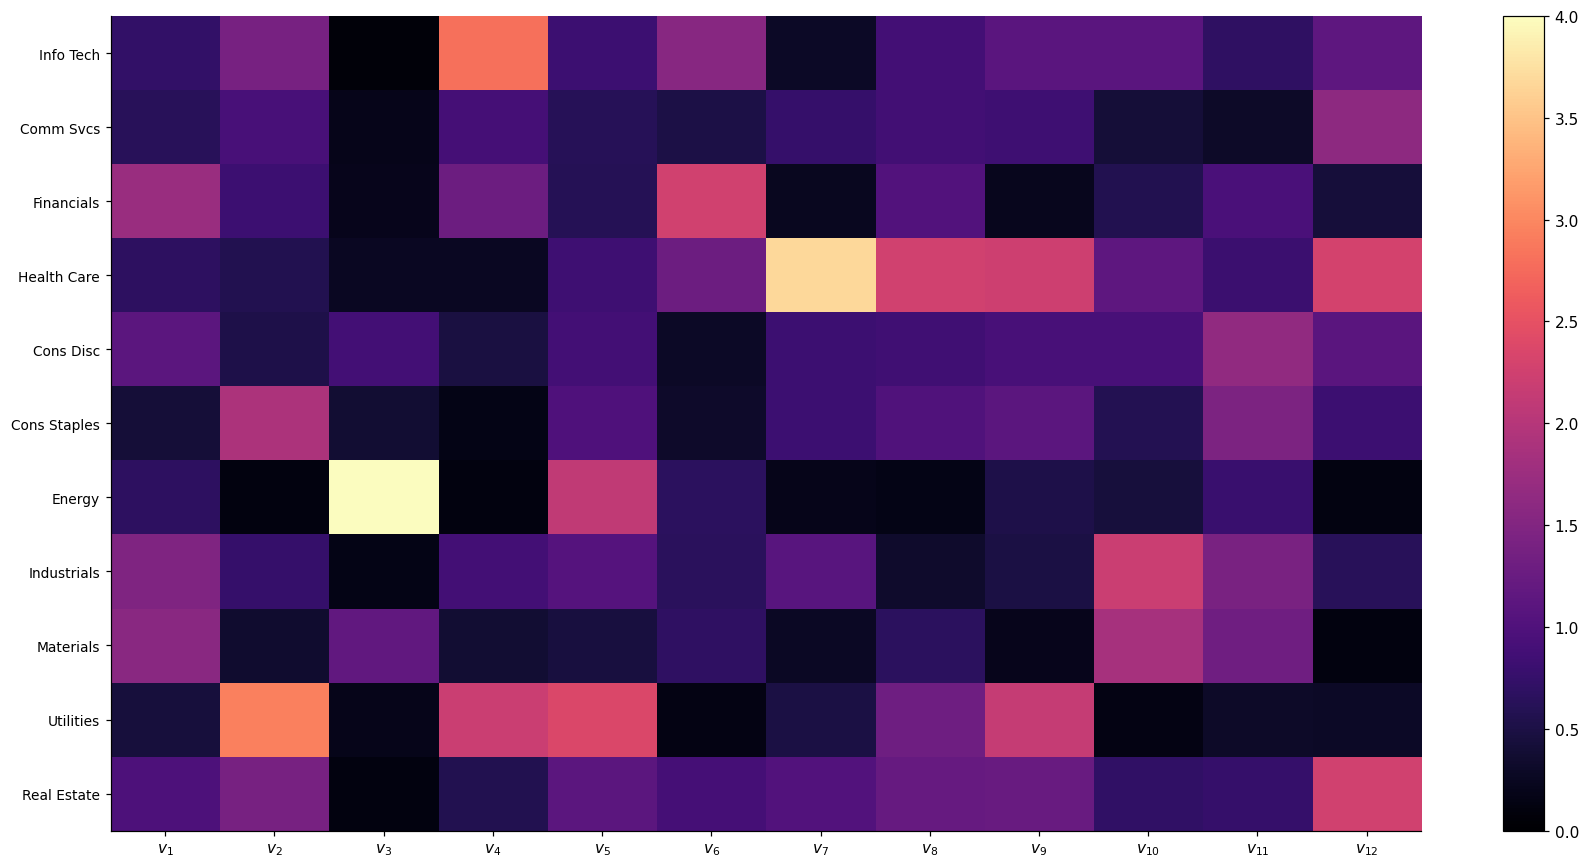

In [79]:
if px is not None:
    K = min(max(n_eff, 6), 12)
    W = np.zeros((len(sec_list), K))                      # sector share of each mode's weight
    for k in range(K):
        for si, s in enumerate(sec_list):
            idx = [i for i, nm in enumerate(names_w) if SECTOR_OF[nm] == s]
            W[si, k] = np.sum(U_w[idx, k] ** 2)
    share = np.array([sum(1 for nm in names_w if SECTOR_OF[nm] == s) for s in sec_list]) / len(names_w)

    fig, ax = plt.subplots(figsize=(1.05 * K + 3.5, 8))
    im = ax.imshow(W / share[:, None], aspect="auto", cmap="magma", vmin=0, vmax=4)
    ax.set_xticks(range(K)); ax.set_xticklabels([f"$v_{{{k+1}}}$" for k in range(K)])
    ax.set_yticks(range(len(sec_list))); ax.set_yticklabels(sec_list, fontsize=9)
    ax.grid(False)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()

The heatmap above just gives us a reading  of the concentration ratio, i.e., a mode's weight share in a sector divided by that sector's share of the the whole data. We see that: 

- As anticipated, $v_3$ is **Energy at ratio $\approx 4$, with 70% of its weight in the sector**. We also note that its IPR of $0.038$ is nearly three times the delocalised reference. Importantly, the localisation is on a full sectro on just a name, in contrast with the results we had in `narrative_rmt_simulations.ipynb` Part 4 where fat-tailed noise concentrated on a single name.
- $v_2$ tilts to Utilities (ratio $\approx 3$) against Info Tech;
- $v_7$ is Health Care at ratio $\approx 3.7$, whilst $v_4$ is Info Tech at $\approx 3$.
- $v_1$, by contrast, is flat across its whole column with a ratio near $1$ everywhere.

In [80]:
if px is not None:
    K = min(max(n_eff, 6), 12)
    rows = []
    for k in range(K):
        v = U_w[:, k]
        ell_hat = spike_ell_from_lambda(lam_w[k] / sig2_eff, q_eff)
        ov2 = spike_overlap2(ell_hat, q_eff) if np.isfinite(ell_hat) else np.nan
        top3 = np.argsort(-np.abs(v))[:3]
        sec_w = {s: np.sum(v[[i for i, nm in enumerate(names_w) if SECTOR_OF[nm] == s]] ** 2)
                 for s in sec_list}
        dom = max(sec_w, key=sec_w.get)
        rows.append({
            "lambda": round(float(lam_w[k]), 2),
            "implied ell": round(float(ell_hat), 2) if np.isfinite(ell_hat) else np.nan,
            "overlap^2": round(float(ov2), 3) if np.isfinite(ov2) else np.nan,
            "IPR": round(ipr(v).item(), 4),
            "sign split": f"{int((v > 0).sum())}+/{int((v < 0).sum())}-",
            "dominant sector": f"{dom} ({100*sec_w[dom]:.0f}%)",
            "top 3 names": ", ".join(names_w[i] for i in top3),
        })
    modes = pd.DataFrame(rows, index=[f"v_{k+1}" for k in range(K)])
    print(f"BBP threshold at q_eff={q_eff:.3f}: ell* = {bbp_threshold(q_eff):.3f}   |   "
          f"delocalised IPR reference 3/N = {3/Nw:.4f}")
    display(modes)

BBP threshold at q_eff=0.429: ell* = 1.655   |   delocalised IPR reference 3/N = 0.0139


,lambda,implied ell,overlap^2,IPR,sign split,dominant sector,top 3 names
v_1,47.21,59.70,0.993,0.0068,216+/0-,Financials (24%),"ITW, MET, TFC"
v_2,22.75,28.53,0.984,0.0109,116+/100-,Info Tech (19%),"ED, DUK, SO"
v_3,9.26,11.32,0.956,0.0380,119+/97-,Energy (70%),"COP, XOM, EOG"
v_4,8.98,10.97,0.955,0.0170,111+/105-,Info Tech (39%),"NOW, CRM, INTU"
v_5,6.83,8.21,0.936,0.0108,98+/118-,Energy (15%),"PEG, WMB, KMI"
v_6,5.10,5.98,0.905,0.0119,82+/134-,Financials (31%),"WFC, PNC, TFC"
v_7,3.83,4.32,0.851,0.0188,97+/119-,Health Care (49%),"ELV, HUM, UNH"
v_8,3.22,3.51,0.796,0.0152,121+/95-,Health Care (30%),"CVS, ELV, CI"
v_9,3.04,3.25,0.769,0.0165,115+/101-,Health Care (30%),"UNH, ELV, HUM"
v_10,2.88,3.03,0.739,0.0208,121+/95-,Industrials (28%),"NOC, LMT, GD"


Now, with our nice table we can stop being happy. I cannot stress this enough: **numquam gaudium**.

Indeed, if we look at the results we see that: 

- **We can sharpen the interpretation of the heatmap**. To wit, (i) $v_3$ is COP, XOM, EOG; (ii) $v_7$ is ELV, HUM, UNH, CVS, CI (*managed care*, not health care at large); (iii) $v_{10}$ is NOC, LMT, GD, the defence primes; and finally (iv) $v_6$ is WFC, PNC, TFC, regional banks. In other words, the top of the ESD is reconstructing an industry taxonomy without prior information about it!

- **The `overlap^2` kills all of the enthusiasm**. Just look at it. Below $v_6$ the overlap drops below 90%. It is just sad. To be more precise. It reads $0.99$ for the market, $0.98$ for $v_2$, $0.96$ for Energy, and $0.95$ for $v_4$, i.e., we have some trustworthy directions. Then the decay. Unstoppable. Really sad. We find: $0.85$ at $v_7$, $0.74$ at $v_{10}$, $0.64$ at $v_{11}$, $0.57$ at $v_{12}$. The last of these are *detected* with total confidence, and yet *roughly 40% of the direction is sampling noise*. **Part N + 100 of detected $\neq$ estimated**.

- **The sign split also matters**. We see a $216+/0-$ for the market, whilst everything below it is near-balanced (roughly $110+/106-$). This is just because sector modes are *relative* trades carrying no net market exposure. That is why they can be traded (if I understood correctly, of course.)

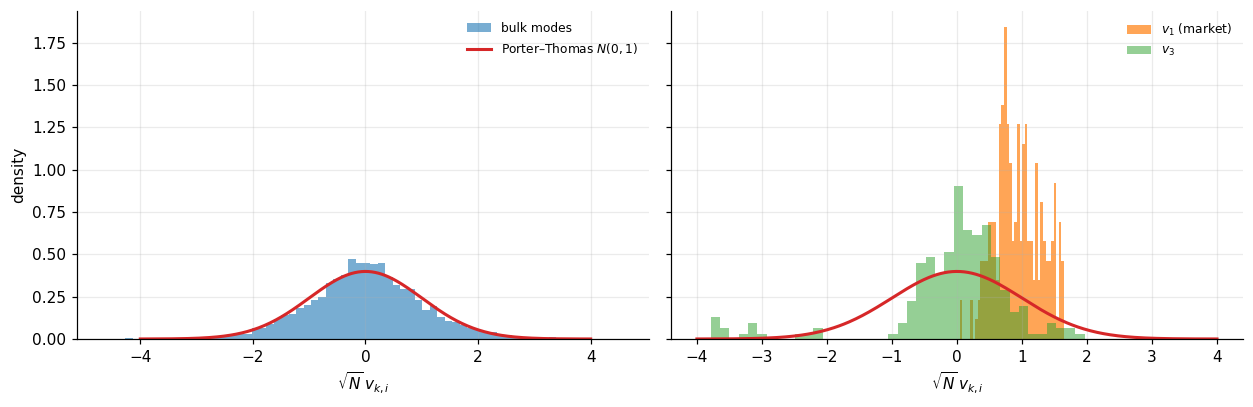

In [81]:
if px is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
    xs = np.linspace(-4, 4, 400)
    pt = np.exp(-xs ** 2 / 2) / np.sqrt(2 * np.pi)

    bulk_idx = range(max(n_eff, 5) + 5, max(n_eff, 5) + 25)          # deep in the bulk
    comps = np.concatenate([U_w[:, k] * np.sqrt(Nw) for k in bulk_idx])
    ax1.hist(comps, bins=70, density=True, color=C0, alpha=0.6, label="bulk modes")
    ax1.plot(xs, pt, color=C3, lw=2, label="Porter–Thomas $N(0,1)$")
    ax1.set_xlabel(r"$\sqrt{N}\,v_{k,i}$"); ax1.set_ylabel("density"); ax1.legend(fontsize=8)

    ax2.hist(U_w[:, 0] * np.sqrt(Nw), bins=40, density=True, color=C1, alpha=0.7,
             label=f"$v_1$ (market)")
    ax2.hist(U_w[:, 2] * np.sqrt(Nw), bins=40, density=True, color=C2, alpha=0.5,
             label=f"$v_3$")
    ax2.plot(xs, pt, color=C3, lw=2)
    ax2.set_xlabel(r"$\sqrt{N}\,v_{k,i}$"); ax2.legend(fontsize=8)
    plt.tight_layout()

Finally, we can also implement the original eigenvector test proposed in Laloux, Cizeau, Bouchaud & Potters (1999), PRL 83, 1467, but of course reproduced on our 2024–26 data. To wit, the components of a *noise* eigenvector, rescaled by $\sqrt{N}$, should be distributed as $N(0,1)$ (as featurless as possible).

What do we find?-

- **The bulk passes, with no adjustable parameters** — the blue histogram sits on the red curve. The bulk really is just MP. No information to be gained there.

- **The top modes fail the test.** The market mode is a narrow lump centred near $+0.9$ with **no negative side at all**, whilst e.g., $v_3$ presents a skewed concentrated distribution.

This is all good. However, we have been looking at the top of the spectrum. What about the bottom? 

#### The other end of the spectrum

Before looking at the bottom of the ESD, just a not-so-brief reminder of what matter in portfolio-building and what does what. This is for me too dear reader, do not worry. 

To begin with the weights optained by looking for a mean variance portfolio are given by $w \propto \hat{E}^{-1}\mathbf{1}$ enetering along a direction with strength $1/\xi_i$, where the $\xi_i$ are the *estimated* eigenvalues. It is the smallest of those, not the largest, that decide what a portfolio actually does. Remember as well that here $\hat{E}$ is the SCM (maybe even cleaned, right now it does not matter), and $C$ is the true population covariance.

One thing this does **not** mean, however, is that then $C^{-1}$ should be the thing to estimate well. For a given $\hat{E}$ the out-of-sample risk $w^{\top} C\, w$ contains the unknown $C$ *linearly*, exactly once, so $C$ should really be the 
estimation target. To wit, the out-of-sample portfolio not the in-sample one should be our target to reduce as much as possible. Or in other words: because we cleaned the SCM, the weights on the fragile directions are no longer far too large, and we are no longer understating what they cost. See Chapter 20 of Potters & Bouchaud *A First Course in Random Matrix Theory* (2020) for a more in-depth discussion.

Finally, remember that even by estimating at best $C$, this does not mean bringing about the min variance portfolio (see e.g., Bongiorno & Challet 2021, arXiv:2112.07521).

So, it is really worth remembering the three pieces: (i) the estimated small eigenvalues drive the weights (this
section), (ii) $C$ is what to estimate to reduce out-of-sample risk, and (iii) the gap between "best matrix" and "best portfolio" is not necessary zero.

So, so, so... the bottom of the ESD.

In [82]:
if px is not None:
    lo_edge = mp_edges(q_eff, sig2_eff)[0]
    below = lam_w < lo_edge
    print(f"MP band [{lo_edge:.3f}, {edge_eff:.3f}]   |   "
          f"{int(below.sum())} eigenvalues BELOW the lower edge")
    print(f"smallest lambda = {lam_w[-1]:.4f}")
    print(f"those {int(below.sum())} modes carry {100*lam_w[below].sum()/Nw:.2f}% of the trace "
          f"(and an inverse weights them by 1/lambda)")
    rows = []
    for k in range(1, 7):
        v = U_w[:, -k]
        top = np.argsort(-np.abs(v))[:4]
        rows.append({"lambda": round(float(lam_w[-k]), 4),
                     "IPR": round(ipr(v).item(), 3),
                     "dominant loadings": ", ".join(f"{names_w[i]}({v[i]:+.2f})" for i in top)})
    display(pd.DataFrame(rows, index=[f"v_{Nw-k+1}" for k in range(1, 7)]))

MP band [0.093, 2.151]   |   36 eigenvalues BELOW the lower edge
smallest lambda = 0.0280
those 36 modes carry 1.00% of the trace (and an inverse weights them by 1/lambda)


,lambda,IPR,dominant loadings
v_216,0.0280,0.061,"DHI(+0.37), LRCX(+0.37), LEN(-0.33), AMAT(-0.24)"
v_215,0.0304,0.033,"KLAC(-0.27), MPC(-0.26), PNC(-0.26), VLO(+0.24)"
v_214,0.0319,0.029,"MLM(+0.29), PSX(+0.26), VMC(-0.25), OXY(+0.21)"
v_213,0.0332,0.025,"MCO(-0.27), SPGI(+0.25), LRCX(+0.21), KLAC(-0.20)"
v_212,0.0349,0.032,"SPGI(-0.32), MCO(+0.30), PSX(+0.23), KLAC(-0.20)"
v_211,0.0374,0.036,"LRCX(+0.33), USB(+0.27), KLAC(-0.25), V(-0.24)"


**We find eigenvalues outside of MP, jsut at the bottom. DANGER!** Thirty-six eigenvalues sit *below* the lower edge carrying together only about $1\%$ of the trace. These are those who can dominate the portfolio. 

**These factors are not noise.** Their IPRs stays between $0.025$–$0.061$, namely two to four times the delocalised reference. if we look at their composition, these look like **spread trades between near-identical businesses**.

Interestingly in Bouchaud, Mastromatteo, Potters & Tikhonov (2022), arXiv:2205.01012, a similar structure is reported for the risk associated to **futures**. We might look into it later on.

## Part 3 — Tails or signal? A volatility-filtering experiment 

In Parts 1 and 2 we identified thirteen eigenvalue outliers and zoned in on six of these as (possibly) genuine market factors by looking at the eigenvectors. Of course, the underlying assumptions - which we have to never forget -  are of 
a Gaussian, stationary noise. 

However, since we did our due diligence, we also saw that the factor count is infleted under fat tails, and that the MP spectra clearly fails to fit the ESD. 

It is time to look at what is going on.

Our suspision carries over from the results of Part 5 of the simulation notebook. If volatility is **common, time-varying and fat-tailed**, then a handful of wild days dominate every sum in $\hat{E}$ and the spectrum could be measuring *when the market was loud* rather than *what co-moves with what*. 

Therefore we  **filter out the common volatility**, namley one scale shared by everyone on a given day. We remove it via the cross-sectional MAD (one number per day, no dynamics, no fitting).

Then the question of course is going to be **what survives?** An eigenvalue that shrinks to nothing under filtering was simply fat-tailed noise. 

Ah, importantly, the **tail diagnostics are computed on raw returns only.** Filtering is for the correlation layer. To wit,measuring tails on filtered data would convolute fat tails and fitler.

In [88]:
if px is not None:
    VARIANTS = {
        "raw":           Xw,
        "day-std (MAD)": Xw / day_scale(Xw),
    }

    spec, rows = {}, []
    for nm, Y in VARIANTS.items():
        lam_v, U_v = eigh_desc(sample_corr(Y, demean=True))
        spec[nm] = (lam_v, U_v)
        s2_v, qe_v, edge_v = mp_fit_k(lam_v, Nw, Tw, k=1)
        lo_v = mp_edges(qe_v, s2_v)[0]
        rows.append({"lambda_1": round(float(lam_v[0]), 1),
                     "lambda_2": round(float(lam_v[1]), 1),
                     "lambda_3": round(float(lam_v[2]), 1),
                     "sigma2_eff": round(float(s2_v), 3),
                     "edge": round(float(edge_v), 2),
                     "above edge": int((lam_v > edge_v).sum()),
                     "below lower edge": int((lam_v < lo_v).sum())})
    display(pd.DataFrame(rows, index=list(VARIANTS)))

,lambda_1,lambda_2,lambda_3,sigma2_eff,edge,above edge,below lower edge
raw,47.2,22.7,9.3,0.785,2.15,13,36
day-std (MAD),43.6,17.6,8.8,0.802,2.20,13,26


So, what happens? Well:

**1. We still have thirteen outliers.** Whatever the common daily scale was doing to this spectrum, it was not manufacturing the detections of Parts 1–2. Not a bad result!

**2. The top eigenvalues shrink, and $\lambda_2$ shrinks quite a bit.** $\lambda_1$ goes $47.2 \to 43.6$ ($-8\%$) while $\lambda_2$ goes $22.7 \to 17.6$ ($-22\%$), whilst $\lambda_3$ barely moves ($9.3 \to 8.8$). 

**3. The bottom of the spectrum improves.** Eigenvalues below the lower MP edge fall $36 \to 26$ and the condition number $1688 \to 1201$, hell yeah! Some progress on a dangerous bit.

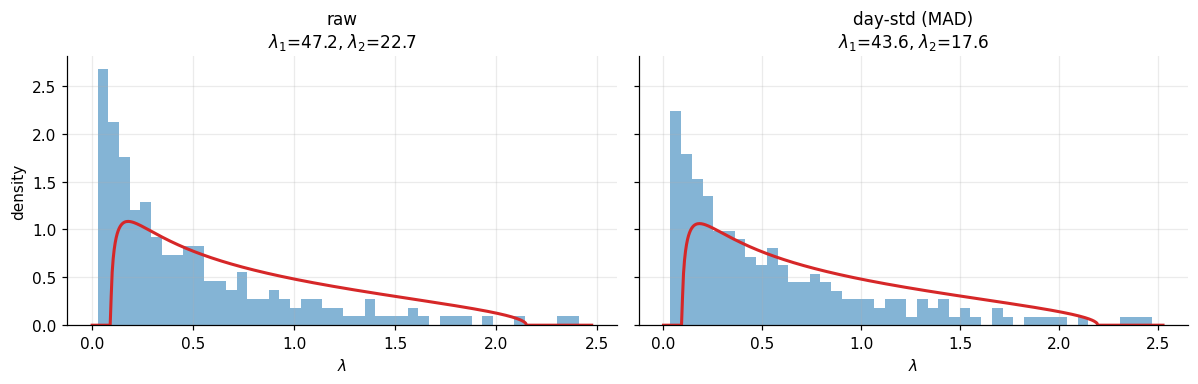

In [90]:
if px is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
    for ax, (nm, (lam_v, _)) in zip(axes, spec.items()):
        s2_v, qe_v, edge_v = mp_fit_k(lam_v, Nw, Tw, k=1)
        ax.hist(lam_v[lam_v < edge_v * 1.15], bins=45, density=True, color=C0, alpha=0.55)
        xs = np.linspace(1e-3, edge_v * 1.15, 500)
        ax.plot(xs, mp_pdf(xs, qe_v, s2_v), color=C3, lw=2)
        ax.set_title(f"{nm}\n$\\lambda_1$={lam_v[0]:.1f}, $\\lambda_2$={lam_v[1]:.1f}")
        ax.set_xlabel(r"$\lambda$")
    axes[0].set_ylabel("density")
    plt.tight_layout()

Sadly, the plot has an unmistakable read. Namely, that  **the bulk is still not MP even after filtering.** The ESD peaks
near $\lambda \approx 0.05$ at about $2.8$ raw and $2.2$ filtered, against MP's $\approx 1.1$. In other words, removing the common scale closes only aboyt a fifth of the gap. Therefore? What we can conclude from this? 

I would say then that perhaps, maybe, we could dare to say that **the population spectrum itself is not white.** MP assumes the truth is a delta at $\sigma^2$ (plus spikes). Clearly, here things work differntly (and not in an elliptical manner!). Indeed, it seems that the S&P's truth might carry a continuum of small eigenvalues due to near-identical businesses create genuinely low-variance directions.

This has immediate consequences when talking about cleaning the matrix then. Indeed, **clipping would assume exactly a model our figure rejects**, i.e., a flat bulk with one $\sigma^2$. RIE and LW do not. Maybe better to use those...

So, we looked at the eigenvalues. But what about the eigenvectors?

In [ ]:
if px is not None:
    lam_raw, U_raw = spec["raw"]
    lam_ds, U_ds = spec["day-std (MAD)"]
    ov = pd.DataFrame({
        "|<v_k raw, v_k day-std>|": [round(abs(float(U_raw[:, k] @ U_ds[:, k])), 2)
                                     for k in range(10)],
        "lambda raw": np.round(lam_raw[:10], 2),
        "lambda day-std": np.round(lam_ds[:10], 2),
    }, index=[f"v_{k+1}" for k in range(10)])
    print("1.00 = the common-volatility filter did not move the directions at all")
    display(ov)

1.00 = the common-volatility filter did not move the direction at all


,"|<v_k raw, v_k day-std>|",lambda raw,lambda day-std
v_1,0.98,47.21,43.58
v_2,0.98,22.75,17.57
v_3,0.93,9.26,8.79
v_4,0.91,8.98,7.26
v_5,0.93,6.83,6.64
v_6,0.95,5.10,4.60
v_7,0.95,3.83,3.73
v_8,0.37,3.22,3.19
v_9,0.10,3.04,3.01
v_10,0.42,2.88,2.85


Well, good damn news everybody!

The top seven directions are essentially untouched. They just do not move! Which is great. Whatever these modes are made of, it is randomness.

Then the column falls off a cliff and so would our happiness if we were not already looking at any asset below $v_7$ as a "no-touchy-zone". But we were. Anyway, we get: $0.37$ at $v_8$, $0.10$ at $v_9$, $0.42$ at $v_{10}$. 

However, a word of caution. If we look at the eigenvalues associated with these modes we see that these are spaced by less than $6\%$. Eigenvectors of near-degenerate eigenvalues are free to rotate within the subspace they share, and any perturbation will spin them. In general, the individual axes are arbitrary, while the *plane* they span is not. Therefore, more than factors being killed maybe we are just looking at the edge of where single mode read out stops making sense. Maybe we should start to track subspace after a bit...

Also, and by the way. How much common volatility is there, truly?

|r| comovement, raw          : lambda_1 =  41.9  ->  19.4%
|r| comovement, after day-std: lambda_1 =  14.9  ->   6.9%
returns comovement, raw      : lambda_1 =  47.2  ->  21.9%


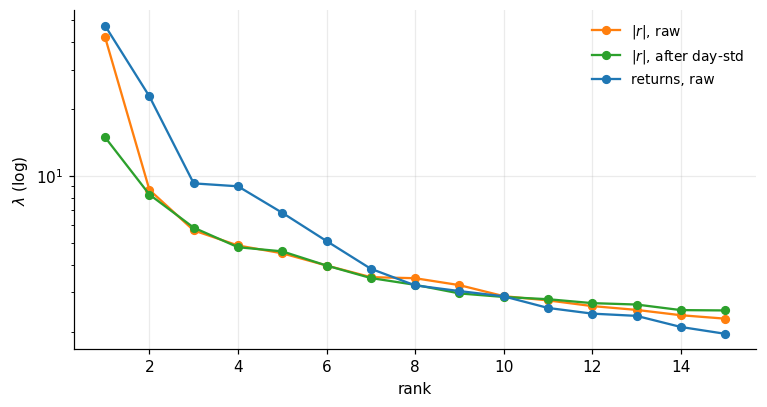

In [91]:
if px is not None:
    absX = np.abs(Xw)                                  # no smoothing, no kernel choice
    absZ = np.abs(Xw / day_scale(Xw))
    lam_a, _ = eigh_desc(sample_corr(absX, demean=True))
    lam_b, _ = eigh_desc(sample_corr(absZ, demean=True))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, 16), lam_a[:15], "o-", color=C1, ms=5, label=r"$|r|$, raw")
    ax.plot(np.arange(1, 16), lam_b[:15], "o-", color=C2, ms=5, label=r"$|r|$, after day-std")
    ax.plot(np.arange(1, 16), lam_raw[:15], "o-", color=C0, ms=5, label="returns, raw")
    ax.set_yscale("log"); ax.set_xlabel("rank"); ax.set_ylabel(r"$\lambda$ (log)")
    ax.legend(fontsize=9)

    print(f"|r| comovement, raw          : lambda_1 = {lam_a[0]:5.1f}  ->  {100*lam_a[0]/Nw:4.1f}%")
    print(f"|r| comovement, after day-std: lambda_1 = {lam_b[0]:5.1f}  ->  {100*lam_b[0]/Nw:4.1f}%")
    print(f"returns comovement, raw      : lambda_1 = {lam_raw[0]:5.1f}  ->  {100*lam_raw[0]/Nw:4.1f}%")

To answer previous question, and whether removing the cross-sectional MAD helps, let us just take $|r|$ and ask how correlated *those* are across names. The above plot is our result. We find that:

**Raw, the common volatility mode is real:** $\lambda_1 = 41.9$, or $19.4\%$ of the cross-sectional variation in $|r|$. To wit volatility co-moves about as strongly as prices do. 

**Day-standardising removes most of it:** the same number falls to $\lambda_1 = 14.9$, or $6.9\%$. Overall, we removed two-thirds of the common volatility mode.

R_2 at the full sample : 0.0043
R_4 at the full sample : 0.1160
kappa(1, 30)           : 0.195     (0 = Gaussian-speed aggregation; t(3) gave 0.184 in the simulation lab)


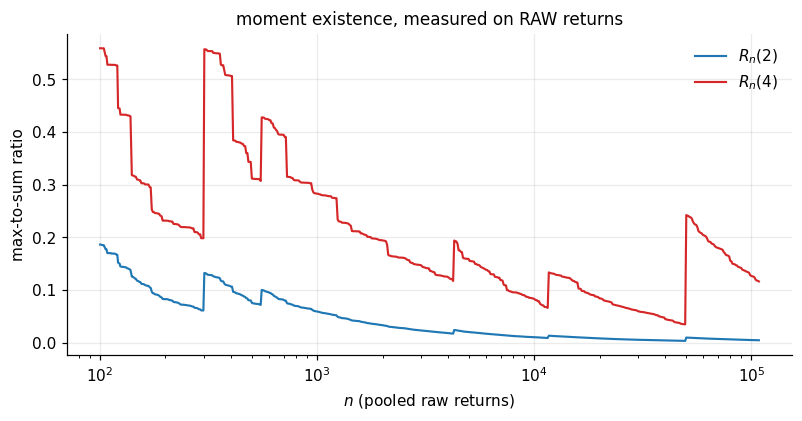

In [87]:
if px is not None:
    pooled = Xw.ravel()
    perm = np.random.default_rng(0).permutation(pooled)     # order is not exchangeable in time
    idx = np.unique(np.logspace(2, np.log10(perm.size - 1), 600).astype(int))

    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for p, c_ in ((2, C0), (4, C3)):
        ax.plot(idx, max_to_sum_ratio(perm, p)[idx], color=c_, lw=1.4, label=f"$R_n({p})$")
    ax.set_xscale("log"); ax.set_xlabel("$n$ (pooled raw returns)")
    ax.set_ylabel("max-to-sum ratio"); ax.legend()
    ax.set_title("moment existence, measured on RAW returns")

    z = pooled / pooled.std()
    rg = np.random.default_rng(1)
    k_hat = kappa(lambda size, g: g.choice(z, size=size, replace=True), 30, rng=rg)
    print(f"R_2 at the full sample : {max_to_sum_ratio(perm, 2)[-1]:.4f}")
    print(f"R_4 at the full sample : {max_to_sum_ratio(perm, 4)[-1]:.4f}")
    print(f"kappa(1, 30)           : {k_hat:.3f}     "
          f"(0 = Gaussian-speed aggregation; t(3) gave 0.184 in the simulation lab)")

Finally let us look at the tails, on  the **raw** returns. No filtering allowed. What do we learn? Well, that:

**$R_n(2)$ sinks to $0.004$ fast, i.e., the variance exists**. Every $L^2$ object in this notebook is therefore measuring
something real at least. How much to trust it is still debatable.

**$R_n(4)$ refuses to sink.** It falls, then jumps, then falls, then jumps and so on and so forth. At $n \approx 300$, again near $4{,}000$, and hardest around $50{,}000$, where a single day drags the ratio from $0.03$ back to $0.24$. **In the end, one observation owns twelve percent of the entire fourth-moment sum** of a hundred thousand returns. 

**At the same time $\kappa(1,30) = 0.195$**, against $0.184$ measured for Student-$t(3)$ in the simulation notebook. The S&P's pooled returns aggregate at almost exactly $t(3)$ speed. As such, we can probably state that **our data have infinite fourth momentum**.

As such, with $R_4$ not converging, **Tracy–Widom edge reasoning breaks**, and so is any volatility model whose parameters are fitted through fourth moments. Furthermore, note that even estimates of second momenta become more suspiscious. As their convergence will be slow and their sample variations are going to be quite large.

One last check, which we run but do not show (trust me, this is getting long and it will get longer). $R_4$ on the *day-standardised* data still jumps, ending at $0.057$ against $0.116$ raw. To wit common volatility explains about half the final fourth-moment concentration, and the rest is single-name shocks (SNPS $-44\%$, DLTR $-25\%$, IDXX $+24\%$) that no elliptical model can, well... model.